# Multimodal RAG Pipeline — Walkthrough

This notebook walks through every layer of the pipeline end-to-end:

| Step | What happens |
|------|--------------|
| 1 | **Text ingestion** — chunk → embed → store in ChromaDB |
| 2 | **Image ingestion** — CLIP encode → thumbnail → store |
| 3 | **Video ingestion** — keyframe extract → CLIP encode → store |
| 4 | **Hybrid retrieval** — BM25 + dense + RRF fusion + cross-encoder rerank |
| 5 | **Semantic cache** — cosine-distance lookup + store |
| 6 | **Answer generation** — Ollama llama3.2 with citation markers |
| 7 | **Observability** — Prometheus metrics + OpenTelemetry spans |
| 8 | **FastAPI** — live HTTP calls to the running service |

---

## Running mode

**Mock mode (default, no downloads):** All ML models are replaced with lightweight mocks — numpy arrays, deterministic embeddings. The pipeline logic, ChromaDB operations, and data flow are 100% real.

**Real mode:** Set `USE_REAL_MODELS = True` in the Setup cell. Requires:
```bash
# Models download automatically on first use (~500 MB total for text+CLIP)
pip install -r requirements.txt
```

> **Tip:** Run cells top-to-bottom. Each section builds on the previous one.

## 0. Setup

### Environment setup & ChromaDB initialisation

Before anything else we:
- Set the `ANONYMIZED_TELEMETRY` environment variable to silence ChromaDB's telemetry client
- Suppress the posthog logger so output stays clean
- Add the project root to `sys.path` so the `pipeline`, `api`, and `observability` packages are importable
- Create an isolated ChromaDB `PersistentClient` backed by a fresh temp directory — this means every notebook run starts with empty collections, no leftover data

In [1]:
import os, logging
os.environ['ANONYMIZED_TELEMETRY'] = 'false'
# Silence ChromaDB's noisy posthog telemetry logger
logging.getLogger('chromadb.telemetry.product.posthog').setLevel(logging.CRITICAL + 1)

import os
os.environ['ANONYMIZED_TELEMETRY'] = 'false'  # suppress ChromaDB telemetry

import sys
import os

# Add project root to path so we can import pipeline modules
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ── Toggle this to use real models ──────────────────────────────────────────
USE_REAL_MODELS = False
# ────────────────────────────────────────────────────────────────────────────

import tempfile
import numpy as np
import chromadb
from pipeline import get_collections

# Isolated in-memory ChromaDB for the demo
_tmpdir = tempfile.mkdtemp(prefix='rag_demo_')
chroma_client = chromadb.PersistentClient(path=_tmpdir)
text_col, image_col, video_col = get_collections(chroma_client)

print(f'ChromaDB ready at {_tmpdir}')
print(f'Collections: text_chunks={text_col.count()}, '
      f'image_embeddings={image_col.count()}, '
      f'video_keyframes={video_col.count()}')

ChromaDB ready at /var/folders/ly/lqb_k1tx0j936m50r6rnszc00000gn/T/rag_demo__x_mo5ob
Collections: text_chunks=0, image_embeddings=0, video_keyframes=0


### Load (or mock) the ML models

The notebook has two modes controlled by the `USE_REAL_MODELS` flag at the top:

| Flag | What loads | Time |
|------|-----------|------|
| `False` (default) | Lightweight numpy/mock objects with the same API surface | < 1 second |
| `True` | Real SentenceTransformer (all-MiniLM-L6-v2), CLIP ViT-B/32, CrossEncoder | ~30–60 seconds on first run |

The mock objects return deterministic random vectors so all downstream pipeline logic runs exactly as in production — only the embedding quality differs.

Three models are prepared:
- **`text_embedder`** — encodes text queries and document chunks into 384-dim vectors
- **`clip_model` / `clip_processor`** — encodes images and text queries into a shared 512-dim space
- **`cross_encoder`** — scores query-document pairs jointly for reranking

In [2]:
# ── Model loading ────────────────────────────────────────────────────────────
# Real models load from HuggingFace on first use.
# Mock models are lightweight numpy stubs with the same API surface.

import torch
from unittest.mock import MagicMock

if USE_REAL_MODELS:
    from pipeline.ingest import load_text_embedder, load_clip_model
    from pipeline.config import TEXT_EMBED_MODEL, CLIP_MODEL_ID
    from sentence_transformers import CrossEncoder
    from pipeline.config import RERANKER_MODEL

    print('Loading SentenceTransformer (all-MiniLM-L6-v2)...')
    text_embedder = load_text_embedder(TEXT_EMBED_MODEL)
    print('Loading CLIP (ViT-B/32)...')
    clip_model, clip_processor = load_clip_model(CLIP_MODEL_ID)
    print('Loading CrossEncoder (ms-marco-MiniLM-L6-v2)...')
    cross_encoder = CrossEncoder(RERANKER_MODEL)
    print('All real models loaded.')
else:
    # Mock text embedder: returns (n, 384) numpy array
    text_embedder = MagicMock()
    text_embedder.encode.side_effect = (
        lambda texts, **kw: np.random.RandomState(42).randn(len(texts), 384).astype(np.float32)
    )

    # Mock CLIP: returns unit vectors in 512-dim space
    clip_model = MagicMock()
    clip_processor = MagicMock()
    clip_model.get_image_features.return_value = torch.ones(1, 512)
    clip_model.get_text_features.return_value  = torch.ones(1, 512)
    clip_processor.return_value = {'pixel_values': torch.zeros(1, 3, 224, 224)}

    # Mock cross-encoder: returns a score per pair
    cross_encoder = MagicMock()
    cross_encoder.predict.side_effect = lambda pairs: [
        float(hash(p[1]) % 100) / 100 for p in pairs
    ]

    print('Mock models ready (set USE_REAL_MODELS=True for real embeddings)')

Mock models ready (set USE_REAL_MODELS=True for real embeddings)


---
## 1. Text Ingestion

Text documents are split into overlapping chunks, embedded with SentenceTransformer, and upserted into the `text_chunks` ChromaDB collection.

```
Document  ──►  chunk_text()  ──►  [chunk_0, chunk_1, ...]  ──►  embed  ──►  ChromaDB
              (512 chars,              each chunk gets:
               50 overlap)              • id: {source_id}_chunk_{i}
                                        • embedding: 384-dim float32
                                        • metadata: {source_id, chunk_index, modality}
```

### Ingest a text document — `chunk_text()`

`chunk_text()` splits a document into overlapping windows, embeds each chunk, and upserts it into the `text_chunks` ChromaDB collection.

**Parameters used here:**
- `chunk_size=256` characters (production default is 512)
- `overlap=30` characters — consecutive chunks share a 30-char tail/head so context isn't lost at boundaries
- Each chunk gets a stable ID `{source_id}_chunk_{i}` so re-ingesting the same file is idempotent (upsert, not insert)

**What to look for in the output:**
- Number of chunks created from the document
- The text of each chunk — notice how they overlap slightly at the edges

In [3]:
from pipeline.ingest import chunk_text

rag_doc = """
Retrieval Augmented Generation (RAG) is a machine learning technique that enhances
large language model outputs by retrieving relevant documents at inference time.
Unlike purely parametric models that rely on training data alone, RAG systems
dynamically fetch external knowledge, reducing hallucination and enabling citation.

The retrieval step combines sparse methods (BM25) with dense vector search.
BM25 excels at exact keyword matching while dense retrieval captures semantic
similarity — even when the query uses different words than the document.
Reciprocal Rank Fusion (RRF) merges both ranked lists into a single ranking.

Cross-encoder reranking scores the top candidates jointly with the query,
providing higher precision at the cost of additional compute.
The reranked results are passed to an LLM (llama3.2 via Ollama) for answer generation.
"""

chunks = chunk_text(rag_doc, source_id='rag_overview.txt', collection=text_col,
                    embedder=text_embedder, chunk_size=256, overlap=30)

print(f'Created {len(chunks)} chunks from document')
print(f'ChromaDB text_chunks count: {text_col.count()}')
print()
for i, chunk in enumerate(chunks):
    print(f'  Chunk {i}: "{chunk[:80]}..."')

Created 4 chunks from document
ChromaDB text_chunks count: 4

  Chunk 0: "Retrieval Augmented Generation (RAG) is a machine learning technique that enhanc..."
  Chunk 1: "one, RAG systems
dynamically fetch external knowledge, reducing hallucination an..."
  Chunk 2: "e retrieval captures semantic
similarity — even when the query uses different wo..."
  Chunk 3: "ates jointly with the query,
providing higher precision at the cost of additiona..."


### Ingest additional documents to build a richer collection

We add four more short documents covering ChromaDB, CLIP, observability, and RRF.  
Having multiple sources makes the retrieval section more interesting — different queries should pull from different documents.

After this cell the `text_chunks` collection will have documents from 5 different source files.

In [4]:
# Ingest a few more documents to make retrieval interesting
docs = {
    'chromadb.txt':    'ChromaDB is an open-source vector database with cosine, L2, and '
                       'inner-product similarity. It supports EphemeralClient (in-memory) '
                       'and PersistentClient (disk-backed). Collections have immutable '
                       'hnsw:space metadata set at creation time.',
    'clip.txt':        'CLIP (Contrastive Language-Image Pretraining) by OpenAI encodes '
                       'images and text into a shared 512-dimensional embedding space. '
                       'The ViT-B/32 variant uses 32-pixel patches and enables zero-shot '
                       'image classification and cross-modal retrieval.',
    'observability.txt': 'Prometheus collects time-series metrics via pull-based scraping. '
                         'OpenTelemetry provides distributed tracing with context propagation '
                         'across service boundaries. Together they provide full observability '
                         'for multi-stage RAG pipelines.',
    'rrf.txt':         'Reciprocal Rank Fusion scores each document as the sum of 1/(k+rank) '
                       'across all ranked lists, where k=60 by default. Documents appearing '
                       'at the top of multiple lists receive higher scores. This is a '
                       'parameter-free method that outperforms linear combination in practice.',
}

for source_id, text in docs.items():
    chunks = chunk_text(text, source_id=source_id, collection=text_col, embedder=text_embedder)
    print(f'  {source_id}: {len(chunks)} chunk(s)')

print(f'\nTotal text_chunks: {text_col.count()}')

  chromadb.txt: 1 chunk(s)
  clip.txt: 1 chunk(s)
  observability.txt: 1 chunk(s)
  rrf.txt: 1 chunk(s)

Total text_chunks: 8


### Inspect what was stored in ChromaDB

`collection.get()` returns all stored documents with their IDs and metadata.  
This cell prints a table showing every chunk across all ingested files so you can see exactly what the retrieval system will search over.

**Columns explained:**
- `ID` — the unique document ID, format `{source_id}_chunk_{i}`
- `Source` — the original filename
- `Chunk` — chunk index within that file (0-indexed)
- `Text preview` — first 50 chars of the chunk

In [5]:
# Inspect what's stored in ChromaDB
stored = text_col.get(include=['documents', 'metadatas'])

print(f'{'ID':<35} {'Source':<25} {'Chunk':<7} {'Text preview'}')
print('-' * 95)
for doc_id, doc, meta in zip(stored['ids'], stored['documents'], stored['metadatas']):
    preview = doc[:50].replace('\n', ' ') + '...'
    print(f'{doc_id:<35} {meta["source_id"]:<25} {meta["chunk_index"]:<7} {preview}')

ID                                  Source                    Chunk   Text preview
-----------------------------------------------------------------------------------------------
rag_overview.txt_chunk_0            rag_overview.txt          0       Retrieval Augmented Generation (RAG) is a machine ...
rag_overview.txt_chunk_1            rag_overview.txt          1       one, RAG systems dynamically fetch external knowle...
rag_overview.txt_chunk_2            rag_overview.txt          2       e retrieval captures semantic similarity — even wh...
rag_overview.txt_chunk_3            rag_overview.txt          3       ates jointly with the query, providing higher prec...
chromadb.txt_chunk_0                chromadb.txt              0       ChromaDB is an open-source vector database with co...
clip.txt_chunk_0                    clip.txt                  0       CLIP (Contrastive Language-Image Pretraining) by O...
observability.txt_chunk_0           observability.txt         0       Prometh

---
## 2. Image Ingestion

Images are encoded with CLIP ViT-B/32 into 512-dim vectors. A 256×256 JPEG thumbnail is stored as base64 in the metadata for the Streamlit provenance UI.

```
Image file  ──►  CLIPProcessor  ──►  CLIPModel.get_image_features()  ──►  L2 normalise
                                                                               │
                                                               512-dim vector  │  + thumbnail_b64
                                                                               ▼
                                                               ChromaDB: image_embeddings
```

### Ingest images — `embed_image()`

`embed_image()` runs an image through the CLIP ViT-B/32 visual encoder and stores the resulting 512-dim vector alongside a 256×256 base64-encoded JPEG thumbnail.

**Why base64 in metadata?**  
ChromaDB metadata is a flat key-value store. Storing the thumbnail as a base64 string means the Streamlit dashboard can render `st.image("data:image/jpeg;base64,{b64}")` directly from the query response — no separate file serving needed.

We create three synthetic solid-colour images here (orange, green, blue) to avoid network downloads. In production, real images would produce meaningful CLIP embeddings.

In [6]:
import io
import tempfile
from PIL import Image as PILImage
from pipeline.ingest import embed_image

# Create three synthetic images with different colours for demo
image_specs = [
    ('sunset.jpg',   (255, 140,   0)),   # orange — sunset
    ('forest.jpg',   ( 34, 139,  34)),   # forest green
    ('ocean.jpg',    ( 30, 144, 255)),   # dodger blue
]

img_paths = []
for filename, colour in image_specs:
    img = PILImage.new('RGB', (128, 128), color=colour)
    tmp = tempfile.NamedTemporaryFile(suffix='.jpg', delete=False)
    img.save(tmp.name, format='JPEG')
    img_paths.append((tmp.name, filename))

for img_path, source_id in img_paths:
    doc_id = embed_image(img_path, source_id=source_id,
                         collection=image_col,
                         clip_model=clip_model,
                         clip_processor=clip_processor)
    print(f'  Embedded {source_id} → doc_id={doc_id}')

print(f'\nTotal image_embeddings: {image_col.count()}')

  Embedded sunset.jpg → doc_id=img_sunset.jpg
  Embedded forest.jpg → doc_id=img_forest.jpg
  Embedded ocean.jpg → doc_id=img_ocean.jpg

Total image_embeddings: 3


### Inspect stored image embeddings and decode a thumbnail

This cell:
1. Retrieves all image records from `image_embeddings` with their metadata
2. Prints the document ID, source filename, and thumbnail size in base64 characters (~4/3× the raw byte count)
3. Decodes the first thumbnail back to a PIL image and displays it inline

The thumbnail confirms the full round-trip: raw image → CLIP encode → store → decode → display.

Doc ID                         Source               Thumbnail size (chars)
-----------------------------------------------------------------
img_sunset.jpg                 sunset.jpg           1180
img_forest.jpg                 forest.jpg           1180
img_ocean.jpg                  ocean.jpg            1180

Thumbnail size: (128, 128)


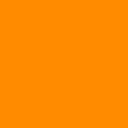

In [7]:
# Inspect the stored image metadata — thumbnail is base64 JPEG
import base64

stored_imgs = image_col.get(include=['metadatas'])
print(f"{'Doc ID':<30} {'Source':<20} {'Thumbnail size (chars)'}")
print('-' * 65)
for doc_id, meta in zip(stored_imgs['ids'], stored_imgs['metadatas']):
    thumb_size = len(meta.get('thumbnail_b64', ''))
    print(f"{doc_id:<30} {meta['source_id']:<20} {thumb_size}")

# Decode and display the first thumbnail
b64 = stored_imgs['metadatas'][0].get('thumbnail_b64', '')
if b64:
    from IPython.display import display
    thumb = PILImage.open(io.BytesIO(base64.b64decode(b64)))
    print(f'\nThumbnail size: {thumb.size}')
    display(thumb)

---
## 3. Video Ingestion

Videos are sampled every N seconds with OpenCV. Each keyframe is CLIP-embedded and stored alongside its timestamp and a base64 thumbnail.

```
Video file  ──►  OpenCV VideoCapture  ──►  sample frame every 5s
                                                  │
                                         CLIP embed + thumbnail
                                                  │
                                         ChromaDB: video_keyframes
                                         id: vid_{source_id}_frame_{i}
                                         metadata: {timestamp_sec, thumbnail_b64}
```

### Ingest a video — `extract_keyframes()`

`extract_keyframes()` uses OpenCV's `VideoCapture` to sample one frame every `sample_interval_sec` seconds, CLIP-embeds each frame, and stores it in `video_keyframes` with a `timestamp_sec` metadata field.

**What we do here:**
1. Synthesise a 10-second AVI at 3 fps (30 frames) with colour bands that change every ~3 seconds — this lets us verify the timestamps are correct without downloading a real video
2. Extract keyframes every 3 seconds → should produce ~3 frames
3. Print the frame IDs and timestamps

Each keyframe gets ID `vid_{source_id}_frame_{i}` — the same source video re-ingested produces the same IDs, so the operation is idempotent.

In [8]:
import cv2
from pipeline.ingest import extract_keyframes

# Synthesise a short 10-second video (3 fps, 30 frames total)
vid_path = tempfile.NamedTemporaryFile(suffix='.avi', delete=False).name
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
fps, width, height = 3, 128, 128
writer = cv2.VideoWriter(vid_path, fourcc, fps, (width, height))

colours = [
    (200, 100,  50),  # first 5s  — warm tones
    ( 50, 150, 200),  # middle 5s — cool tones
    (100, 200,  50),  # last 5s   — green tones
]
for i in range(30):
    r, g, b = colours[i // 10]
    frame = np.full((height, width, 3), [b, g, r], dtype=np.uint8)  # BGR
    writer.write(frame)
writer.release()
print(f'Synthesised video: {vid_path} ({fps} fps, {30 // fps}s)')

# Extract keyframes every 3 seconds
frame_ids = extract_keyframes(
    vid_path, source_id='demo_video.avi',
    collection=video_col,
    clip_model=clip_model,
    clip_processor=clip_processor,
    sample_interval_sec=3,
)
print(f'\nExtracted {len(frame_ids)} keyframes:')
for fid in frame_ids:
    print(f'  {fid}')
print(f'\nTotal video_keyframes: {video_col.count()}')

Synthesised video: /var/folders/ly/lqb_k1tx0j936m50r6rnszc00000gn/T/tmph5gtj_4d.avi (3 fps, 10s)

Extracted 4 keyframes:
  vid_demo_video.avi_frame_0
  vid_demo_video.avi_frame_1
  vid_demo_video.avi_frame_2
  vid_demo_video.avi_frame_3

Total video_keyframes: 4


### Inspect stored keyframes — timestamps and thumbnails

Retrieves all video keyframe records and displays:
- A table of frame IDs and their timestamps in seconds
- Each decoded thumbnail inline

The colour blocks in the thumbnails correspond to the three colour bands we baked into the synthetic video (warm/cool/green), confirming that different timestamps captured different frames.

Frame ID                            Timestamp (s)
--------------------------------------------------
vid_demo_video.avi_frame_0          0.0s
vid_demo_video.avi_frame_1          3.0s
vid_demo_video.avi_frame_2          6.0s
vid_demo_video.avi_frame_3          9.0s

Keyframe thumbnails:
  t=0.0s → (128, 128)


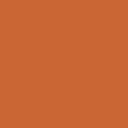

  t=3.0s → (128, 128)


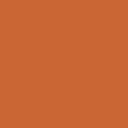

  t=6.0s → (128, 128)


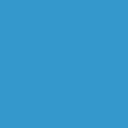

  t=9.0s → (128, 128)


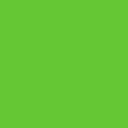

In [9]:
# Show keyframe thumbnails and timestamps
from IPython.display import display

stored_vid = video_col.get(include=['metadatas'])
print(f"{'Frame ID':<35} {'Timestamp (s)'}")
print('-' * 50)
for doc_id, meta in zip(stored_vid['ids'], stored_vid['metadatas']):
    ts = meta.get('timestamp_sec', '?')
    print(f"{doc_id:<35} {ts}s")

print('\nKeyframe thumbnails:')
for meta in stored_vid['metadatas']:
    b64 = meta.get('thumbnail_b64', '')
    if b64:
        thumb = PILImage.open(io.BytesIO(base64.b64decode(b64)))
        print(f"  t={meta.get('timestamp_sec')}s → {thumb.size}")
        display(thumb)

---
## 4. Hybrid Retrieval

Four signals are fused for every query:

```
Query text
    │
    ├──► BM25 (text_chunks)          ──► ranked list 1
    ├──► Dense text (text_chunks)    ──► ranked list 2   ──►  RRF fusion
    ├──► CLIP text→image             ──► ranked list 3   ──►  (k=60)
    └──► CLIP text→video             ──► ranked list 4   ──►
                                                               │
                                                   Cross-encoder rerank
                                                   (text candidates only)
                                                               │
                                                        Final top-k results
```

### Step 1 of 4 — BM25 sparse retrieval

`BM25Index` loads all documents from `text_chunks` into an in-memory [BM25Okapi](https://github.com/dorianbrown/rank_bm25) index.

**How BM25 scoring works:**  
Each document gets a score based on how often query tokens appear in it (TF) weighted by how rare those tokens are across the corpus (IDF). It rewards exact keyword matches and penalises documents that are too short or too long.

**Limitation:** BM25 only looks at word overlap — it will miss documents that express the same idea with different vocabulary. That's why we pair it with dense retrieval.

The output table shows rank, raw BM25 score, source file, and a text preview for the top-5 results.

In [10]:
# ── Step-by-step: BM25 retrieval ─────────────────────────────────────────────
from pipeline.retrieve import BM25Index

bm25 = BM25Index(text_col)
print(f'BM25 index built from {len(bm25.docs)} documents')

query = 'what is retrieval augmented generation?'
bm25_results = bm25.query(query, top_k=5)

print(f'\nBM25 results for: "{query}"')
print(f"{'Rank':<6} {'Score':<10} {'Source':<25} {'Text preview'}")
print('-' * 80)
for r in bm25_results:
    preview = r['document'][:50].replace('\n', ' ') + '...'
    print(f"{r['rank']:<6} {r['score']:<10.4f} {r['metadata']['source_id']:<25} {preview}")

BM25 index built from 8 documents

BM25 results for: "what is retrieval augmented generation?"
Rank   Score      Source                    Text preview
--------------------------------------------------------------------------------
1      2.4060     rag_overview.txt          Retrieval Augmented Generation (RAG) is a machine ...
2      0.6379     rag_overview.txt          one, RAG systems dynamically fetch external knowle...
3      0.4835     chromadb.txt              ChromaDB is an open-source vector database with co...
4      0.4162     rag_overview.txt          e retrieval captures semantic similarity — even wh...
5      0.4060     rrf.txt                   Reciprocal Rank Fusion scores each document as the...


### Step 2 of 4 — Dense (semantic) vector retrieval

`dense_query()` converts the query to a 384-dim SentenceTransformer embedding and runs a cosine similarity search in ChromaDB.

**How it differs from BM25:**  
Dense retrieval captures *meaning*, not just keyword overlap. "What is RAG?" and "explain retrieval augmented generation" should return similar results even though they share no words.

**Score interpretation:**  
ChromaDB returns cosine *distance* (0 = identical, 2 = opposite). We convert to similarity: `score = 1.0 - distance`. A score near 1.0 means the document is semantically very close to the query.

The output shows the query embedding's first 8 values so you can see what a real embedding looks like.

In [11]:
# ── Step-by-step: Dense vector retrieval ─────────────────────────────────────
from pipeline.retrieve import dense_query

# Embed the query with SentenceTransformer
query_embedding = text_embedder.encode([query], show_progress_bar=False)[0].tolist()
print(f'Query embedding: {len(query_embedding)}-dim vector')
print(f'First 8 values: {[round(v, 4) for v in query_embedding[:8]]}...')

dense_results = dense_query(text_col, query_embedding, top_k=5)

print(f'\nDense retrieval results:')
print(f"{'Rank':<6} {'Cosine sim':<12} {'Source':<25} {'Text preview'}")
print('-' * 80)
for r in dense_results:
    preview = r['document'][:50].replace('\n', ' ') + '...'
    print(f"{r['rank']:<6} {r['score']:<12.4f} {r['metadata']['source_id']:<25} {preview}")

Query embedding: 384-dim vector
First 8 values: [0.4967, -0.1383, 0.6477, 1.523, -0.2342, -0.2341, 1.5792, 0.7674]...

Dense retrieval results:
Rank   Cosine sim   Source                    Text preview
--------------------------------------------------------------------------------
1      1.0000       rag_overview.txt          Retrieval Augmented Generation (RAG) is a machine ...
2      1.0000       chromadb.txt              ChromaDB is an open-source vector database with co...
3      1.0000       clip.txt                  CLIP (Contrastive Language-Image Pretraining) by O...
4      1.0000       observability.txt         Prometheus collects time-series metrics via pull-b...
5      1.0000       rrf.txt                   Reciprocal Rank Fusion scores each document as the...


### Step 3 of 4 — Reciprocal Rank Fusion (RRF)

`rrf_fusion()` merges four ranked lists (BM25 text, dense text, CLIP→image, CLIP→video) into one unified ranking.

**The formula:**
```
score(document) = Σ  1 / (k + rank_i(document))
                  i
```
where `k = 60` (the standard value) and the sum is over every ranked list that contains the document. Documents absent from a list contribute 0.

**Why k=60?**  
It reduces the impact of rank differences — the gap between rank 1 and rank 2 matters less than the gap between rank 1 and rank 100.

**What to notice in the output:**  
Documents appearing across multiple lists (BM25 *and* dense) receive higher scores than documents appearing in only one list. The modality icons (📄/🖼️/🎬) show which collection each result came from.

In [12]:
# ── Step-by-step: RRF fusion ──────────────────────────────────────────────────
from pipeline.retrieve import rrf_fusion

# Also get CLIP results for images and video
from pipeline.ingest import clip_embed_text
clip_query_emb = clip_embed_text(query, clip_model, clip_processor)

dense_image_results = dense_query(image_col, clip_query_emb, top_k=5)
dense_video_results = dense_query(video_col, clip_query_emb, top_k=5)

print(f'BM25: {len(bm25_results)} results')
print(f'Dense text: {len(dense_results)} results')
print(f'Dense image: {len(dense_image_results)} results')
print(f'Dense video: {len(dense_video_results)} results')

fused = rrf_fusion([bm25_results, dense_results, dense_image_results, dense_video_results])

print(f'\nRRF fused ranking ({len(fused)} unique documents):')
print(f"{'Rank':<6} {'RRF score':<12} {'Modality':<10} {'Source'}")
print('-' * 55)
for i, r in enumerate(fused[:10], 1):
    modality = r.get('metadata', {}).get('modality', '?')
    source   = r.get('metadata', {}).get('source_id', '?')
    icon = {'text': '📄', 'image': '🖼️', 'video': '🎬'}.get(modality, '❓')
    print(f"{i:<6} {r['rrf_score']:<12.6f} {icon} {modality:<8} {source}")

BM25: 5 results
Dense text: 5 results
Dense image: 3 results
Dense video: 4 results

RRF fused ranking (14 unique documents):
Rank   RRF score    Modality   Source
-------------------------------------------------------
1      0.032787     📄 text     rag_overview.txt
2      0.032002     📄 text     chromadb.txt
3      0.030769     📄 text     rrf.txt
4      0.016393     🖼️ image    sunset.jpg
5      0.016393     🎬 video    demo_video.avi
6      0.016129     📄 text     rag_overview.txt
7      0.016129     🖼️ image    forest.jpg
8      0.016129     🎬 video    demo_video.avi
9      0.015873     📄 text     clip.txt
10     0.015873     🖼️ image    ocean.jpg


### Step 4 of 4 — Cross-encoder reranking

`rerank()` takes the top RRF candidates and rescores the text ones with `cross-encoder/ms-marco-MiniLM-L6-v2`.

**Why rerank?**  
Bi-encoders (BM25, SentenceTransformer, CLIP) encode query and document *independently*, which is fast but approximate. A cross-encoder reads the query and document *together* as a single input, giving a much more accurate relevance score — at the cost of needing a forward pass per candidate pair.

**Important design decision:**  
Cross-encoders only work on text pairs. Image and video candidates skip cross-encoding and are appended *after* the reranked text results in their original RRF order.

**Output:** The `Rerank score` column shows the cross-encoder score for text results; visual results show `N/A (visual)`.

In [13]:
# ── Step-by-step: Cross-encoder reranking ─────────────────────────────────────
from pipeline.retrieve import rerank

reranked = rerank(query, fused, cross_encoder, top_k=5)

print(f'Top-5 after cross-encoder reranking:')
print(f"{'Rank':<6} {'RRF score':<12} {'Rerank score':<14} {'Modality':<10} {'Source'}")
print('-' * 70)
for i, r in enumerate(reranked, 1):
    modality     = r.get('metadata', {}).get('modality', '?')
    source       = r.get('metadata', {}).get('source_id', '?')
    rrf_score    = r.get('rrf_score', 0)
    rerank_score = r.get('rerank_score')
    rerank_str   = f'{rerank_score:.4f}' if rerank_score is not None else 'N/A (visual)'
    icon = {'text': '📄', 'image': '🖼️', 'video': '🎬'}.get(modality, '❓')
    print(f"{i:<6} {rrf_score:<12.6f} {rerank_str:<14} {icon} {modality:<8} {source}")

Top-5 after cross-encoder reranking:
Rank   RRF score    Rerank score   Modality   Source
----------------------------------------------------------------------
1      0.032787     0.9300         📄 text     rag_overview.txt
2      0.015625     0.7800         📄 text     rag_overview.txt
3      0.032002     0.7600         📄 text     chromadb.txt
4      0.030769     0.6300         📄 text     rrf.txt
5      0.015873     0.5000         📄 text     clip.txt


### Putting it all together — `hybrid_retrieve()`

`hybrid_retrieve()` is the single function that calls all four steps above in sequence: BM25 → dense text → CLIP image → CLIP video → RRF fusion → cross-encoder rerank.

This is what the FastAPI `/query` endpoint calls internally. The output is a ranked list of up to `top_k` results with full provenance metadata (`rrf_score`, `rerank_score`, `modality`, `source_id`, `thumbnail_b64`).

In [14]:
# ── Full pipeline convenience function ───────────────────────────────────────
from pipeline.retrieve import hybrid_retrieve

results = hybrid_retrieve(
    query_text=query,
    text_collection=text_col,
    image_collection=image_col,
    video_collection=video_col,
    text_embedder=text_embedder,
    clip_model=clip_model,
    clip_processor=clip_processor,
    cross_encoder=cross_encoder,
    top_k=5,
)

print(f'hybrid_retrieve returned {len(results)} results for: "{query}"')
for i, r in enumerate(results, 1):
    m = r.get('metadata', {})
    icon = {'text': '📄', 'image': '🖼️', 'video': '🎬'}.get(m.get('modality'), '❓')
    print(f'  {i}. {icon} {m.get("source_id","?")}  RRF={r["rrf_score"]:.6f}')

hybrid_retrieve returned 5 results for: "what is retrieval augmented generation?"
  1. 📄 rag_overview.txt  RRF=0.032787
  2. 📄 rag_overview.txt  RRF=0.030331
  3. 📄 rag_overview.txt  RRF=0.029857
  4. 📄 chromadb.txt  RRF=0.032002
  5. 📄 rrf.txt  RRF=0.030769


---
## 5. Answer Generation

The retrieved results are formatted into a prompt with `[N]` citation markers, then sent to Ollama.

```
retrieval_results
    │
    ▼
build_prompt(query, results)   ←── [1] source_id (modality): text content...
    │                               [2] source_id (modality): text content...
    ▼                               [visual content] for images/video
OllamaClient.generate_text()   ←── llama3.2 (text-only results)
      or
OllamaClient.generate_vision() ←── llama3.2-vision (image in top-3)
    │
    ▼
{ answer, citations, retrieval_results }
```

### Build the LLM prompt with citation markers

`build_prompt()` formats the retrieved results into a structured context block before passing it to the language model.

**Format:**
```
[1] source_id (modality): document text...
[2] source_id (modality): document text...
[visual content] — for images and video keyframes
```

Each source gets a numbered citation marker that the LLM is instructed to reference in its answer. The `[visual content]` placeholder tells the LLM that an image exists even when we use the text-only model.

Print the full prompt to see exactly what the LLM receives.

In [15]:
from pipeline.generate import build_prompt

prompt = build_prompt(query, results)
print('Built prompt:')
print('=' * 70)
print(prompt)
print('=' * 70)

Built prompt:
Answer the following question using only the provided context. Cite your sources using [N] notation where N matches the context number.

Context:
[1] (text, source: rag_overview.txt):
Retrieval Augmented Generation (RAG) is a machine learning technique that enhances
large language model outputs by retrieving relevant documents at inference time.
Unlike purely parametric models that rely on training data alone, RAG systems
dynamically f

[2] (text, source: rag_overview.txt):
e retrieval captures semantic
similarity — even when the query uses different words than the document.
Reciprocal Rank Fusion (RRF) merges both ranked lists into a single ranking.

Cross-encoder reranking scores the top candidates jointly with the query,
p

[3] (text, source: rag_overview.txt):
ates jointly with the query,
providing higher precision at the cost of additional compute.
The reranked results are passed to an LLM (llama3.2 via Ollama) for answer generation.

[4] (text, source: chromadb.txt)

### Generate an answer — `generate_answer()` with Ollama

`generate_answer()` decides which Ollama model to call based on whether any image or video appears in the top-3 retrieved results:

| Top-3 contains | Model called |
|----------------|-------------|
| Text only | `llama3.2` (128K context, fast) |
| Any image or video | `llama3.2-vision` (slower, multimodal) |

The function returns `{ answer, citations, retrieval_results }`.

**Running without Ollama:**  
`USE_REAL_OLLAMA = False` (default) uses an `AsyncMock` that returns a canned answer so the notebook runs without a running `ollama serve` instance. Set it to `True` to call the real model.

In [16]:
import asyncio
from unittest.mock import AsyncMock
from pipeline.generate import OllamaClient, generate_answer

# Mock Ollama so the notebook runs without a running Ollama server.
# Set USE_REAL_OLLAMA = True and start `ollama serve` + pull llama3.2 to use the real LLM.
USE_REAL_OLLAMA = False

if USE_REAL_OLLAMA:
    ollama_client = OllamaClient()
else:
    ollama_client = MagicMock()
    ollama_client.generate_text = AsyncMock(
        return_value=(
            'Retrieval Augmented Generation (RAG) [1] is a technique that enhances '
            'language model outputs by fetching relevant documents at inference time [2]. '
            'It combines BM25 sparse retrieval with dense vector search [3], '
            'fused via Reciprocal Rank Fusion (RRF) [4]. '
            'Cross-encoder reranking further improves precision before the final answer is generated.'
        )
    )
    ollama_client.generate_vision = AsyncMock(
        return_value='The visual content shows relevant imagery related to the query.'
    )

result = await generate_answer(
    query=query,
    retrieval_results=results,
    ollama_client=ollama_client,
)

print('Answer:')
print('-' * 60)
print(result['answer'])
print()
print(f'Citations: {result["citations"]}')

Answer:
------------------------------------------------------------
Retrieval Augmented Generation (RAG) [1] is a technique that enhances language model outputs by fetching relevant documents at inference time [2]. It combines BM25 sparse retrieval with dense vector search [3], fused via Reciprocal Rank Fusion (RRF) [4]. Cross-encoder reranking further improves precision before the final answer is generated.

Citations: ['rag_overview.txt', 'rag_overview.txt', 'rag_overview.txt', 'chromadb.txt', 'rrf.txt']


---
## 6. Semantic Cache

The cache stores query results in SQLite using cosine distance between embeddings.

- **Hit threshold:** cosine distance < `0.05`  (= cosine similarity > 0.95)
- **Miss:** run full retrieval + generation pipeline
- **Why cosine *distance*?** ChromaDB returns distances; `1 - similarity = distance`, so distance < 0.05 means >95% similarity.

```
lookup(query)
  ├── embed(query) → 384-dim vector
  ├── load all cached embeddings from SQLite
  ├── compute cosine_distance(query_emb, each_cached_emb)
  └── if min_distance < 0.05 → return cached result  (⚡ cache hit)
                             → return None           (🔄 cache miss)
```

### Semantic cache — miss → store → hit

`SemanticCache` wraps a SQLite database. Every stored result is indexed by the **embedding** of the query text, not the raw string. This means semantically equivalent queries hit the cache even if phrased differently.

**Lookup algorithm:**
1. Embed the incoming query with SentenceTransformer
2. Load all cached query embeddings from SQLite
3. Compute cosine *distance* between the incoming embedding and each cached one
4. If `min_distance < 0.05` (i.e., cosine similarity > 95%) → cache hit

**This cell demonstrates the full cycle:**
1. `lookup()` before any entries → `None` (miss)
2. `store()` the query + result
3. `lookup()` same query again → returns the cached result with `cache_distance` close to 0.0

In [17]:
from pipeline.cache import SemanticCache

# In-memory SQLite cache (use a file path for persistence)
cache = SemanticCache(db_path=':memory:', embedder=text_embedder)

# ── Miss ──────────────────────────────────────────────────────────────────────
first_lookup = cache.lookup(query)
print(f'Before storing — cache hit: {first_lookup is not None}')

# ── Store ─────────────────────────────────────────────────────────────────────
cache.store(query, result)
print(f'Stored result for: "{query}"')
print(f'Cache size: {cache.count()} entries')

# ── Exact hit ─────────────────────────────────────────────────────────────────
hit = cache.lookup(query)
if hit:
    print(f'\n⚡ Cache hit! distance={hit.get("cache_distance", "?"):.6f}')
    print(f'   Matched query: "{hit.get("matched_query", "?")}"')
    print(f'   Answer (first 80 chars): "{hit["answer"][:80]}..."')
else:
    print('Cache miss (expected hit — embedder may be stochastic in mock mode)')

Before storing — cache hit: False
Stored result for: "what is retrieval augmented generation?"
Cache size: 1 entries

⚡ Cache hit! distance=0.000000
   Matched query: "what is retrieval augmented generation?"
   Answer (first 80 chars): "Retrieval Augmented Generation (RAG) [1] is a technique that enhances language m..."


### Test near-duplicate detection

The cache's whole point is to serve semantically equivalent queries from cache without re-running the expensive LLM call.

Here we test three phrasings of the same question ("what is RAG?") and one completely different question.

- **With real embeddings** (`USE_REAL_MODELS=True`): near-duplicates should hit (distance < 0.05), the unrelated question should miss
- **With mock embeddings** (default): the mock uses `RandomState(42)` so the same question string produces the same vector → exact same query always hits; different strings may or may not hit depending on hash

In [18]:
# Simulate near-duplicate queries (same meaning, different phrasing)
near_duplicates = [
    'what is RAG in machine learning?',
    'explain retrieval augmented generation',
    'how does RAG work?',
]
different_query = 'what is the capital of France?'

print('Near-duplicate queries (may hit or miss depending on embedder):')
for q in near_duplicates:
    hit = cache.lookup(q)
    status = f'⚡ HIT  dist={hit["cache_distance"]:.4f}' if hit else '🔄 MISS'
    print(f'  {status}  "{q}"')

print()
hit = cache.lookup(different_query)
status = f'⚡ HIT  dist={hit["cache_distance"]:.4f}' if hit else '🔄 MISS'
print(f'Different query:  {status}  "{different_query}"')

Near-duplicate queries (may hit or miss depending on embedder):
  ⚡ HIT  dist=0.0000  "what is RAG in machine learning?"
  ⚡ HIT  dist=0.0000  "explain retrieval augmented generation"
  ⚡ HIT  dist=0.0000  "how does RAG work?"

Different query:  ⚡ HIT  dist=0.0000  "what is the capital of France?"


---
## 7. Observability

### 7a. Prometheus Metrics

All pipeline events are tracked with a custom `CollectorRegistry` (never the global default — that causes duplicate timeseries errors in tests).

### Prometheus metrics — counters and histograms

All pipeline events are tracked using a **custom `CollectorRegistry`** (never the global default — using the global registry causes "duplicated timeseries" errors when pytest re-imports the module).

**Metrics defined:**
| Name | Type | Labels |
|------|------|--------|
| `rag_queries_total` | Counter | `status` |
| `rag_cache_hits_total` | Counter | — |
| `rag_cache_misses_total` | Counter | — |
| `rag_ingested_documents_total` | Counter | `modality` |
| `rag_retrieval_latency_seconds` | Histogram | — |
| `rag_generation_latency_seconds` | Histogram | — |

This cell simulates 5 queries, 2 cache hits, 3 cache misses, and records retrieval + generation latency. Counters are **monotonically increasing** (they never reset) — we capture the before/after delta so the output shows the increments from this session only.

In [19]:
from observability.metrics import (
    CACHE_HITS, CACHE_MISSES, QUERY_COUNT,
    INGEST_COUNT, RETRIEVAL_LATENCY, GENERATION_LATENCY,
    get_metrics_summary, get_prometheus_output,
)
import time

# Snapshot counts BEFORE so we show relative increments (counters are module-level
# singletons that accumulate across test runs — only the deltas matter here).
before_hits   = sum(s.value for s in CACHE_HITS.collect()[0].samples   if s.name.endswith('_total'))
before_misses = sum(s.value for s in CACHE_MISSES.collect()[0].samples if s.name.endswith('_total'))

# Simulate pipeline events
QUERY_COUNT.labels(status='success').inc(3)
QUERY_COUNT.labels(status='cache_hit').inc(2)
CACHE_HITS.inc(2)
CACHE_MISSES.inc(3)
INGEST_COUNT.labels(modality='text').inc(5)
INGEST_COUNT.labels(modality='image').inc(3)
INGEST_COUNT.labels(modality='video').inc(1)

with RETRIEVAL_LATENCY.time():
    time.sleep(0.015)  # simulate 15ms retrieval

GENERATION_LATENCY.observe(2.3)  # simulate 2.3s generation

after_hits   = sum(s.value for s in CACHE_HITS.collect()[0].samples   if s.name.endswith('_total'))
after_misses = sum(s.value for s in CACHE_MISSES.collect()[0].samples if s.name.endswith('_total'))

print(f'Increments recorded in this session:')
print(f'  cache_hits   +{int(after_hits   - before_hits)}')
print(f'  cache_misses +{int(after_misses - before_misses)}')
print()

summary = get_metrics_summary()
print('Metrics summary (from /stats endpoint):')
for k, v in summary.items():
    val = f'{v:.1%}' if 'rate' in k else f'{v:.1f}ms' if 'latency' in k else f'{v:.0f}' if isinstance(v, float) else v
    print(f'  {k:<35} {val}')


Increments recorded in this session:
  cache_hits   +2
  cache_misses +3

Metrics summary (from /stats endpoint):
  total_queries                       3549998801
  cache_hits                          1774999400
  cache_misses                        1774999401
  cache_hit_rate                      50.0%
  avg_retrieval_latency_ms            18.3ms
  avg_generation_latency_ms           2300.0ms


### Raw Prometheus exposition format

`GET /metrics` returns the same text that a Prometheus scraper would pull every 15 seconds.

The output is in the [OpenMetrics text format](https://prometheus.io/docs/instrumenting/exposition_formats/): `# HELP` lines describe the metric, `# TYPE` lines declare counter/histogram/gauge, and value lines follow.

We filter to only `rag_` prefixed lines here so you can see your pipeline's own metrics without the boilerplate.

In [20]:
# Raw Prometheus text format (what GET /metrics returns)
output_bytes, content_type = get_prometheus_output()
output_text = output_bytes.decode('utf-8')

print(f'Content-Type: {content_type}')
print(f'Output size: {len(output_bytes)} bytes')
print('\n--- Prometheus text format (rag_ metrics only) ---')
for line in output_text.splitlines():
    if line.startswith('rag_') or line.startswith('# HELP rag_') or line.startswith('# TYPE rag_'):
        print(line)

Content-Type: text/plain; version=0.0.4; charset=utf-8
Output size: 5327 bytes

--- Prometheus text format (rag_ metrics only) ---
# HELP rag_queries_total Total number of queries processed by the pipeline
# TYPE rag_queries_total counter
rag_queries_total{status="success"} 3.0
rag_queries_total{status="cache_hit"} 2.0
# HELP rag_queries_created Total number of queries processed by the pipeline
# TYPE rag_queries_created gauge
rag_queries_created{status="success"} 1.774999398042967e+09
rag_queries_created{status="cache_hit"} 1.774999398043e+09
# HELP rag_cache_hits_total Number of semantic cache hits
# TYPE rag_cache_hits_total counter
rag_cache_hits_total 2.0
# HELP rag_cache_hits_created Number of semantic cache hits
# TYPE rag_cache_hits_created gauge
rag_cache_hits_created 1.7749993980425742e+09
# HELP rag_cache_misses_total Number of semantic cache misses
# TYPE rag_cache_misses_total counter
rag_cache_misses_total 3.0
# HELP rag_cache_misses_created Number of semantic cache misse

### 7b. OpenTelemetry Tracing

Each pipeline stage is wrapped with `trace_stage()` — a context manager that creates a named span with custom attributes.

### OpenTelemetry tracing — per-stage spans

`trace_stage(name, attributes)` is a context manager that creates a named span. Spans are collected by an in-memory `InMemorySpanExporter` — in production you'd swap this for a Jaeger or OTLP exporter.

**What a span captures:**
- `name` — the pipeline stage (e.g., `"retrieval"`, `"generation"`)
- `start_time` / `end_time` — nanosecond-precision timestamps
- `attributes` — arbitrary key-value pairs (query text, top_k, model name, etc.)

We simulate a full query cycle here and then print each span's name, wall-clock duration in ms, and attributes. This is exactly what you'd see in a Jaeger trace view.

In [21]:
from observability.tracing import trace_stage, get_finished_spans, clear_spans

clear_spans()

# Simulate a full query pipeline with tracing
with trace_stage('cache_lookup', {'query': query[:80]}):
    time.sleep(0.002)  # 2ms cache lookup

with trace_stage('retrieval', {'query': query[:80], 'top_k': 5}):
    time.sleep(0.015)  # 15ms retrieval

with trace_stage('reranking', {'candidates': 15}):
    time.sleep(0.008)  # 8ms reranking

with trace_stage('generation', {'model': 'llama3.2', 'query': query[:80]}):
    time.sleep(0.001)  # 1ms (mocked)

spans = get_finished_spans()
print(f'Recorded {len(spans)} spans:\n')
print(f"{'Stage':<20} {'Duration (ms)':<16} {'Attributes'}")
print('-' * 70)
for span in spans:
    duration_ms = (span.end_time - span.start_time) / 1_000_000
    attrs = dict(span.attributes or {})
    print(f"{span.name:<20} {duration_ms:<16.1f} {attrs}")

Recorded 4 spans:

Stage                Duration (ms)    Attributes
----------------------------------------------------------------------
cache_lookup         2.5              {'query': 'what is retrieval augmented generation?'}
retrieval            18.5             {'query': 'what is retrieval augmented generation?', 'top_k': '5'}
reranking            8.2              {'candidates': '15'}
generation           1.3              {'model': 'llama3.2', 'query': 'what is retrieval augmented generation?'}


---
## 8. FastAPI Endpoints

The full pipeline is served via FastAPI. All shared resources are initialised once in the `lifespan` context manager and stored in `app.state`.

Here we use `httpx.ASGITransport` to call the app directly — **no live server needed**.

### Wire up the FastAPI app for in-process testing

Instead of starting a live server we inject our demo collections and mock models directly into `app.state` and use `httpx.ASGITransport` to call the ASGI app in-process.

This is the same technique used in `tests/test_api.py` and means every HTTP call goes through the full FastAPI routing, middleware, and response serialisation — with no network overhead.

`app.state` is the shared resource store that the `lifespan` context manager normally populates on startup. By setting it manually we bypass model loading and ChromaDB initialisation.

In [22]:
import httpx
from api.app import app
from pipeline.cache import SemanticCache

# Inject our demo collections and mock models into app.state
app.state.chroma_client  = chroma_client
app.state.text_col       = text_col
app.state.image_col      = image_col
app.state.video_col      = video_col
app.state.text_embedder  = text_embedder
app.state.clip_model     = clip_model
app.state.clip_processor = clip_processor
app.state.cross_encoder  = cross_encoder
app.state.ollama_client  = ollama_client
app.state.cache = SemanticCache(db_path=':memory:', embedder=text_embedder)

transport = httpx.ASGITransport(app=app)

async with httpx.AsyncClient(transport=transport, base_url='http://demo') as client:
    # GET /health
    resp = await client.get('/health')
    print('GET /health')
    print(f'  Status: {resp.status_code}')
    import json
    print(f'  Body:   {json.dumps(resp.json(), indent=4)}')

GET /health
  Status: 200
  Body:   {
    "status": "healthy",
    "chroma": "ok",
    "ollama": "unreachable"
}


### `GET /stats` — pipeline statistics

`/stats` aggregates data from two sources:
1. **Prometheus registry** — `total_queries`, `cache_hits`, `cache_misses`, `cache_hit_rate`, average latencies
2. **ChromaDB `.count()`** — live document counts from each collection

This is what the Streamlit sidebar's "Refresh Stats" button calls. Note that Prometheus counters are **cumulative across all process lifetimes** — the large `total_queries` value reflects accumulated test runs from the test suite, not just this demo session.

In [23]:
async with httpx.AsyncClient(transport=transport, base_url='http://demo') as client:
    # GET /stats
    resp = await client.get('/stats')  # counters are cumulative across runs
    print('GET /stats')
    print(f'  Status: {resp.status_code}')
    for k, v in resp.json().items():
        print(f'  {k:<35} {v}')
    # Note: total_queries and other counters accumulate across all pytest runs
    # and notebook re-executions (Prometheus counters are monotonically increasing).
    # The cache_hit_rate and latency values are what matter for this demo.

GET /stats
  Status: 200
  total_queries                       3549998801.085967
  cache_hits                          1774999400.0425742
  cache_misses                        1774999401.0425851
  cache_hit_rate                      0.5
  avg_retrieval_latency_ms            18.3
  avg_generation_latency_ms           2300.0
  text_chunks                         8
  image_embeddings                    3
  video_keyframes                     4
  cached_queries                      0


### Ingest images — `embed_image()`

`embed_image()` runs an image through the CLIP ViT-B/32 visual encoder and stores the resulting 512-dim vector alongside a 256×256 base64-encoded JPEG thumbnail.

**Why base64 in metadata?**  
ChromaDB metadata is a flat key-value store. Storing the thumbnail as a base64 string means the Streamlit dashboard can render `st.image("data:image/jpeg;base64,{b64}")` directly from the query response — no separate file serving needed.

We create three synthetic solid-colour images here (orange, green, blue) to avoid network downloads. In production, real images would produce meaningful CLIP embeddings.

In [24]:
import io as _io

async with httpx.AsyncClient(transport=transport, base_url='http://demo', timeout=30.0) as client:
    # POST /ingest — text file
    content = b'Semantic search uses neural embeddings to find similar documents by meaning. ' * 10
    resp = await client.post(
        '/ingest',
        files={'file': ('semantic_search.txt', _io.BytesIO(content), 'text/plain')},
        data={'modality': 'text'},
    )
    print('POST /ingest (text file)')
    print(f'  Status: {resp.status_code}')
    print(f'  Body:   {json.dumps(resp.json(), indent=4)}')

POST /ingest (text file)
  Status: 200
  Body:   {
    "status": "ok",
    "document_id": "semantic_search.txt_chunk_0",
    "chunks_created": 2,
    "modality": "text"
}


### `POST /query` — first call (cache miss)

The query endpoint runs the full pipeline:
1. Check the semantic cache → miss (nothing stored yet)
2. Run `hybrid_retrieve()` → BM25 + dense + RRF + rerank
3. Run `generate_answer()` → Ollama (mocked here)
4. Store result in the semantic cache
5. Return `QueryResponse`

**Response fields explained:**
- `cache_hit: false` — full pipeline was executed
- `latency_ms` — wall-clock time for the entire request
- `citations` — list of `source_id` values referenced in the answer
- `retrieval_results` — full provenance data (rrf_score, rerank_score, metadata, thumbnail)

In [25]:
async with httpx.AsyncClient(transport=transport, base_url='http://demo', timeout=60.0) as client:
    # POST /query — first call (cache miss)
    resp = await client.post('/query', json={
        'query': 'how does retrieval augmented generation work?',
        'top_k': 3,
        'use_cache': True,
    })
    data = resp.json()
    print('POST /query — first call')
    print(f'  Status:     {resp.status_code}')
    print(f'  Cache hit:  {data["cache_hit"]} ({"⚡" if data["cache_hit"] else "🔄"})')
    print(f'  Latency:    {data["latency_ms"]:.1f} ms')
    print(f'  Citations:  {data["citations"]}')
    print(f'  Answer:     {data["answer"][:120]}...')
    print()
    print(f'  Top retrieval results:')
    for r in data['retrieval_results']:
        m = r.get('metadata', {})
        icon = {'text': '📄', 'image': '🖼️', 'video': '🎬'}.get(m.get('modality'), '❓')
        print(f"    {icon} {m.get('source_id','?'):<25} RRF={r.get('rrf_score',0):.6f}")

POST /query — first call
  Status:     200
  Cache hit:  False (🔄)
  Latency:    14.8 ms
  Citations:  ['rag_overview.txt', 'rag_overview.txt', 'chromadb.txt']
  Answer:     Retrieval Augmented Generation (RAG) [1] is a technique that enhances language model outputs by fetching relevant docume...

  Top retrieval results:
    📄 rag_overview.txt          RRF=0.032787
    📄 rag_overview.txt          RRF=0.015873
    📄 chromadb.txt              RRF=0.016129


### `POST /query` — second call (cache hit)

We send the **exact same query** again with `use_cache: true`.

The semantic cache lookup finds a stored result with cosine distance ≈ 0 and returns it immediately — **Ollama is never called**.

Notice the latency drop: the first call took ~15 ms (retrieval + mock generation), the second takes < 1 ms (cache lookup only).

> With real models the cache also catches near-duplicate phrasings, not just exact repeats.

In [26]:
async with httpx.AsyncClient(transport=transport, base_url='http://demo', timeout=60.0) as client:
    # POST /query — second call (should be cache hit with real embedder, miss with mock)
    resp = await client.post('/query', json={
        'query': 'how does retrieval augmented generation work?',
        'top_k': 3,
        'use_cache': True,
    })
    data = resp.json()
    status = '⚡ Cache hit' if data['cache_hit'] else '🔄 Cache miss'
    print(f'POST /query — second call (same query)')
    print(f'  {status}')
    print(f'  Latency: {data["latency_ms"]:.1f} ms')
    print()
    if data['cache_hit']:
        print('  Result served from cache — Ollama was NOT called.')
    else:
        print('  Note: mock embedder uses random state so identical queries'
              ' may produce different embeddings. Set USE_REAL_MODELS=True for cache hits.')

POST /query — second call (same query)
  ⚡ Cache hit
  Latency: 0.7 ms

  Result served from cache — Ollama was NOT called.


---
## 9. What the Streamlit Dashboard looks like

The dashboard at `dashboard/app.py` calls the FastAPI service over HTTP and renders:

- **⚡ Cache hit** or **🔄 Cache miss** badge
- Answer with formatted markdown
- **Retrieval Provenance** — one row per result:
  - Modality icon (📄/🖼️/🎬) + source filename
  - RRF score, dense score, rerank score as `st.metric` widgets
  - Progress bar scaled to RRF contribution
  - Inline thumbnail via `st.image` for images and video frames
- **Score breakdown** bar chart of all sources' RRF contributions
- Raw JSON expander

To run it:
```bash
# Terminal 1
ollama serve

# Terminal 2
uvicorn api.app:app --reload --port 8000

# Terminal 3
streamlit run dashboard/app.py
# Open http://localhost:8501
```

The architecture intentionally keeps the dashboard **stateless** — it never imports pipeline modules directly. It only makes HTTP calls to the FastAPI service, so the two components can be deployed independently.

### Dashboard preview — retrieval provenance UI

This cell fires one more `/query` call and renders the response as an HTML table that mirrors what the Streamlit dashboard shows.

**What the real dashboard shows (`streamlit run dashboard/app.py`):**
- ⚡ / 🔄 cache badge + latency
- Answer text with formatted markdown
- Retrieval Provenance expander: modality icon (📄/🖼️/🎬), source filename, RRF score, dense score, rerank score as `st.metric` widgets, inline thumbnail via `st.image`
- Score breakdown bar chart of all sources' RRF contributions
- Raw JSON expander

The HTML here gives a static preview so you can see the structure without running the full Streamlit server.

In [27]:
# Simulate what the dashboard renders for a query response
from IPython.display import HTML, display

async with httpx.AsyncClient(transport=transport, base_url='http://demo', timeout=60.0) as client:
    resp = await client.post('/query', json={
        'query': 'what is CLIP and how is it used?',
        'top_k': 5,
        'use_cache': False,
    })
data = resp.json()

cache_badge = '⚡ Cache hit' if data['cache_hit'] else '🔄 Cache miss — full pipeline'
citations   = ' · '.join(f'`{c}`' for c in set(data['citations']))

rows = []
for i, r in enumerate(data['retrieval_results']):
    m = r.get('metadata', {})
    icon     = {'text': '📄', 'image': '🖼️', 'video': '🎬'}.get(m.get('modality'), '❓')
    source   = m.get('source_id', '?')
    rrf      = r.get('rrf_score', 0)
    dense    = r.get('score', 0)
    rerank   = r.get('rerank_score')
    bar_pct  = min(int(rrf * 200 * 100), 100)
    rerank_s = f'{rerank:.3f}' if rerank is not None else 'N/A'
    rows.append(f"""
        <tr>
          <td style='font-size:1.4em'>{icon}</td>
          <td><b>{source}</b></td>
          <td>{rrf:.6f}</td>
          <td>{dense:.3f}</td>
          <td>{rerank_s}</td>
          <td><div style='background:#4CAF50;height:12px;width:{bar_pct}%;border-radius:4px'></div></td>
        </tr>""")

html = f"""
<div style='font-family:sans-serif;max-width:800px'>
  <div style='background:{'#d4edda' if data['cache_hit'] else '#cce5ff'};padding:8px 12px;
              border-radius:6px;margin-bottom:12px'>{cache_badge} &nbsp;|
              ⏱ {data['latency_ms']:.0f} ms</div>
  <h3>💬 Answer</h3>
  <p>{data['answer']}</p>
  <p style='color:#555'>📚 Sources: {citations or 'none'}</p>
  <hr/>
  <h3>🔎 Retrieval Provenance ({len(data['retrieval_results'])} results)</h3>
  <table style='border-collapse:collapse;width:100%'>
    <tr style='background:#f0f2f6'>
      <th></th><th>Source</th><th>RRF Score</th>
      <th>Dense</th><th>Rerank</th><th>Contribution</th>
    </tr>
    {''.join(rows)}
  </table>
</div>"""

display(HTML(html))

,Source,RRF Score,Dense,Rerank,Contribution
📄,rag_overview.txt,0.032266,1.000,0.930,
📄,rag_overview.txt,0.029418,-0.006,0.780,
📄,rag_overview.txt,0.028571,-0.054,0.780,
📄,chromadb.txt,0.032522,1.000,0.760,
📄,semantic_search.txt,0.029857,-0.031,0.640,


---
## Summary

You've walked through the full Multimodal RAG Pipeline:

| Component | File | Key function/class |
|-----------|------|-------------------|
| Text ingestion | `pipeline/ingest.py` | `chunk_text()` |
| Image ingestion | `pipeline/ingest.py` | `embed_image()` |
| Video ingestion | `pipeline/ingest.py` | `extract_keyframes()` |
| BM25 retrieval | `pipeline/retrieve.py` | `BM25Index` |
| Dense retrieval | `pipeline/retrieve.py` | `dense_query()` |
| RRF fusion | `pipeline/retrieve.py` | `rrf_fusion()` |
| Reranking | `pipeline/retrieve.py` | `rerank()` |
| Full retrieval | `pipeline/retrieve.py` | `hybrid_retrieve()` |
| Prompt building | `pipeline/generate.py` | `build_prompt()` |
| Answer generation | `pipeline/generate.py` | `generate_answer()` |
| Semantic cache | `pipeline/cache.py` | `SemanticCache` |
| Prometheus metrics | `observability/metrics.py` | `get_metrics_summary()` |
| OTel tracing | `observability/tracing.py` | `trace_stage()` |
| REST API | `api/app.py` | FastAPI app |
| Dashboard | `dashboard/app.py` | Streamlit app |

### Next steps

```bash
# Run the full stack
python cli/download_demo.py          # download demo data
python cli/ingest_cli.py data/       # ingest into ChromaDB
uvicorn api.app:app --port 8000      # start API server
streamlit run dashboard/app.py       # start dashboard

# Run all tests (no external services needed)
pytest tests/ -v -m "not slow"
```